开始模拟：N=100, σ=20.0°, T=1.0, M=5000 次/方向，共 37 个方向
------------------------------------------------------------


刺激方向: 100%|██████████| 37/37 [01:24<00:00,  2.30s/it]



模拟完成。
图像已保存至 simulation_q4.png

── 数值摘要（均值 ± std，跨所有测试方向）──
  CRLB 均值              : 17.7248 ± 4.3091 度²
  MSE(MLE) 均值          : 19.0340 ± 4.9728 度²
  MSE(PV)  均值          : 25.7018 ± 23.2996 度²
  效率 MSE(MLE)/CRLB     : 1.0697  (理想值 ≈ 1.0)
  效率 MSE(PV)/CRLB      : 1.2999  (理想值 ≈ 1.0)
  偏差(MLE) 绝对均值     : 0.1874 度
  偏差(PV)  绝对均值     : 1.9640 度

── 中心区域 s∈[30°,150°] 摘要 ──
  CRLB 均值              : 15.3360 度²
  MSE(MLE) 中心均值          : 16.2303 度²
  MSE(PV)  中心均值          : 15.1274 度²
  效率 MSE(MLE)/CRLB     : 1.0563
  效率 MSE(PV)/CRLB      : 0.9894
  偏差(MLE) 绝对均值     : 0.0754 度
  偏差(PV)  绝对均值     : 0.4318 度


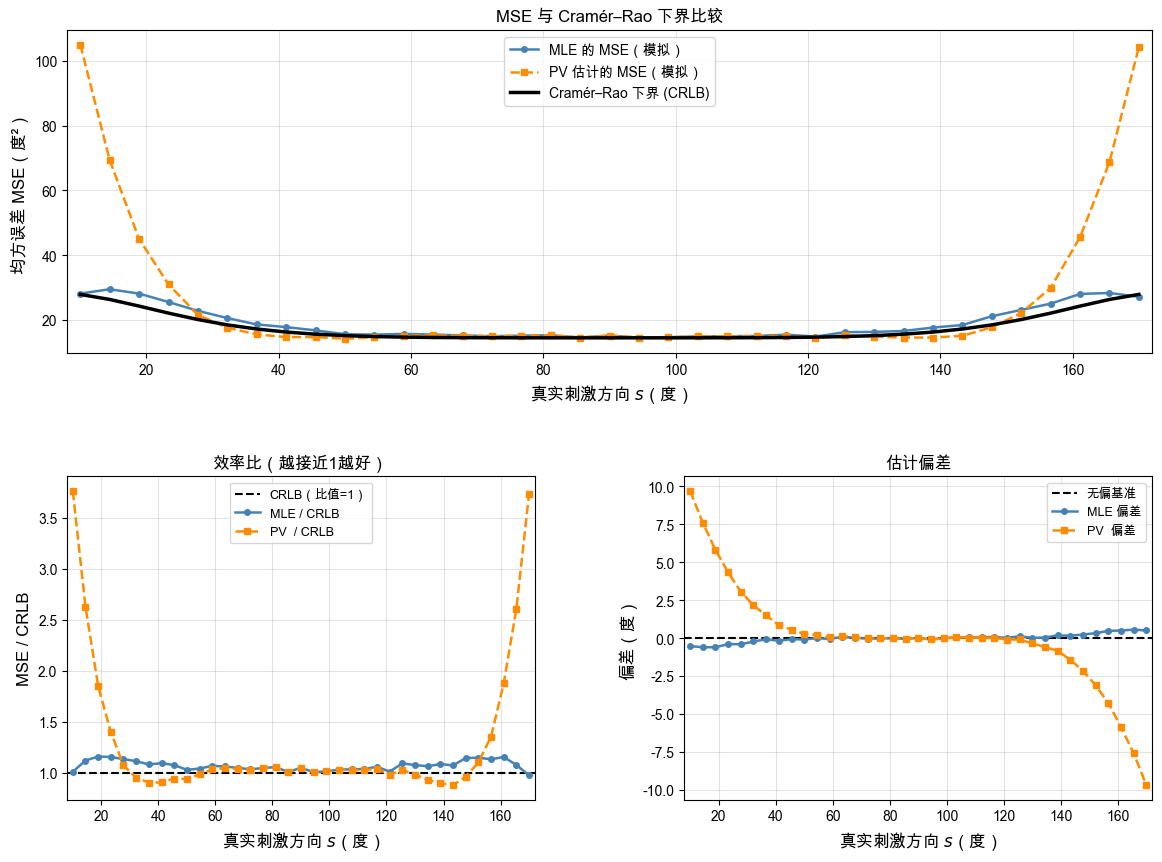

In [2]:
"""
第4题数值模拟：多神经元群体编码的 MVUB 估计
=============================================
模型：
    - N 个神经元，调谐函数 f_a(s) = exp(-(s-s_a)^2 / (2*sigma^2))
    - spike count: k_a ~ Poisson(T * f_a(s))
    - 估计量1：MLE（改进：粗网格定位 + Brent 精细化）
    - 估计量2：Population Vector Estimator (PV)
    - 理论基准：Cramér–Rao 下界 (CRLB)
修改说明（v2）：
    - MLE 求解改为"粗网格定位峰值区间 → Brent 法精细化"，避免边界失效
    - 网格粗搜索点数提升至 500，Brent 在峰值±10°区间内求根
    - 图保存路径改为当前目录（去除硬编码绝对路径）
    - tqdm 进度条加 leave=True，终端输出更整洁
    - 数值摘要补充标准差
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from scipy.optimize import brentq
from tqdm import tqdm
import platform
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ── 中文字体自动配置（跨平台）──
def _set_chinese_font():
    system = platform.system()
    if system == "Darwin":
        candidates = ["Arial Unicode MS", "Heiti TC", "STHeiti",
                      "PingFang SC", "Hiragino Sans GB"]
    elif system == "Windows":
        candidates = ["Microsoft YaHei", "SimHei", "SimSun"]
    else:
        candidates = ["WenQuanYi Micro Hei", "Noto Sans CJK SC",
                      "DejaVu Sans"]
    from matplotlib import font_manager
    available = {f.name for f in font_manager.fontManager.ttflist}
    for font in candidates:
        if font in available:
            rcParams["font.family"] = font
            break
    rcParams["axes.unicode_minus"] = False

_set_chinese_font()

# ───────────────────────────── 参数设置 ──────────────────────────────
N      = 100
sigma  = 20.0
T      = 1.0
M      = 5000
S_MIN  = 0.0
S_MAX  = 180.0
N_TEST = 37

s_a    = np.linspace(S_MIN, S_MAX, N)
s_test = np.linspace(10.0, 170.0, N_TEST)

# 粗网格（全局用一次，供 MLE 定位峰值）
GRID_COARSE = np.linspace(S_MIN, S_MAX, 500)

# ───────────────────────────── 核心函数 ──────────────────────────────

def lambda_a_vec(s, s_a, sigma, T):
    """泊松均值 λ_a(s)，s 为标量，返回 (N,)"""
    return T * np.exp(-0.5 * ((s - s_a) / sigma) ** 2)

def log_likelihood_grid(k, s_a, sigma, T, grid):
    """在 grid 上批量计算对数似然，返回 (len(grid),)"""
    # lam: (len(grid), N)
    lam = T * np.exp(-0.5 * ((grid[:, None] - s_a[None, :]) / sigma) ** 2)
    lam = np.maximum(lam, 1e-300)
    return np.sum(k[None, :] * np.log(lam) - lam, axis=1)

def score(s_hat, k, s_a, sigma, T):
    """Score function（令其为0求 MLE）"""
    lam    = lambda_a_vec(s_hat, s_a, sigma, T)
    weight = (s_hat - s_a) / sigma**2
    return np.sum(weight * (k - lam))

def mle_estimate(k, s_a, sigma, T):
    """
    改进的 MLE 求解：
      1. 粗网格对数似然，定位峰值附近区间 [peak-delta, peak+delta]
      2. 在该区间内用 Brent 法精确求解 score=0
      3. 若 Brent 失败（score 同号），直接取粗网格峰值
    """
    ll = log_likelihood_grid(k, s_a, sigma, T, GRID_COARSE)
    peak_idx = np.argmax(ll)
    s_peak   = GRID_COARSE[peak_idx]

    delta = max(3 * sigma, 15.0)          # 搜索半径
    lo    = max(S_MIN + 1e-6, s_peak - delta)
    hi    = min(S_MAX - 1e-6, s_peak + delta)

    try:
        f_lo = score(lo, k, s_a, sigma, T)
        f_hi = score(hi, k, s_a, sigma, T)
        if f_lo * f_hi < 0:
            return brentq(score, lo, hi, args=(k, s_a, sigma, T), xtol=1e-6)
    except Exception:
        pass
    return s_peak   # 退化到粗网格峰值

def pv_estimate(k, s_a):
    """Population Vector Estimator"""
    total = np.sum(k)
    if total == 0:
        return np.nan
    return np.sum(k * s_a) / total

def fisher_information(s, s_a, sigma, T):
    lam    = lambda_a_vec(s, s_a, sigma, T)
    dlam   = -((s - s_a) / sigma**2) * lam
    return np.sum(dlam**2 / np.maximum(lam, 1e-300))

def crlb(s, s_a, sigma, T):
    return 1.0 / fisher_information(s, s_a, sigma, T)

# ───────────────────────────── 主模拟循环 ──────────────────────────────

print(f"开始模拟：N={N}, σ={sigma}°, T={T}, M={M} 次/方向，共 {N_TEST} 个方向")
print("-" * 60)

mse_mle  = np.zeros(N_TEST)
mse_pv   = np.zeros(N_TEST)
crlb_arr = np.zeros(N_TEST)
bias_mle = np.zeros(N_TEST)
bias_pv  = np.zeros(N_TEST)

rng = np.random.default_rng(seed=42)

for i, s in enumerate(tqdm(s_test, desc="刺激方向", leave=True)):
    lam          = lambda_a_vec(s, s_a, sigma, T)
    crlb_arr[i]  = crlb(s, s_a, sigma, T)

    estimates_mle = np.zeros(M)
    estimates_pv  = np.zeros(M)

    for m in range(M):
        k = rng.poisson(lam)
        estimates_mle[m] = mle_estimate(k, s_a, sigma, T)
        estimates_pv[m]  = pv_estimate(k, s_a)

    valid_pv = ~np.isnan(estimates_pv)

    mse_mle[i]  = np.mean((estimates_mle - s) ** 2)
    mse_pv[i]   = np.mean((estimates_pv[valid_pv] - s) ** 2)
    bias_mle[i] = np.mean(estimates_mle) - s
    bias_pv[i]  = np.mean(estimates_pv[valid_pv]) - s

print("\n模拟完成。")

# ───────────────────────────── 绘图 ──────────────────────────────────

fig = plt.figure(figsize=(14, 10))

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── 图1：MSE vs CRLB ──
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(s_test, mse_mle,  'o-',  color='steelblue',  ms=4, lw=1.8,
         label='MLE 的 MSE（模拟）')
ax1.plot(s_test, mse_pv,   's--', color='darkorange', ms=4, lw=1.8,
         label='PV 估计的 MSE（模拟）')
ax1.plot(s_test, crlb_arr, 'k-',  lw=2.5,
         label='Cramér–Rao 下界 (CRLB)')
ax1.set_xlabel('真实刺激方向 $s$（度）', fontsize=12)
ax1.set_ylabel('均方误差 MSE（度²）', fontsize=12)
ax1.set_title('MSE 与 Cramér–Rao 下界比较', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.35)
ax1.set_xlim(s_test[0] - 2, s_test[-1] + 2)

# ── 图2：MSE/CRLB 比值 ──
ax2 = fig.add_subplot(gs[1, 0])
ratio_mle = mse_mle / crlb_arr
ratio_pv  = mse_pv  / crlb_arr
ax2.axhline(1.0, color='k', lw=1.5, ls='--', label='CRLB（比值=1）')
ax2.plot(s_test, ratio_mle, 'o-',  color='steelblue',  ms=4, lw=1.8, label='MLE / CRLB')
ax2.plot(s_test, ratio_pv,  's--', color='darkorange', ms=4, lw=1.8, label='PV  / CRLB')
ax2.set_xlabel('真实刺激方向 $s$（度）', fontsize=12)
ax2.set_ylabel('MSE / CRLB', fontsize=12)
ax2.set_title('效率比（越接近1越好）', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.35)
ax2.set_xlim(s_test[0] - 2, s_test[-1] + 2)

# ── 图3：偏差 Bias ──
ax3 = fig.add_subplot(gs[1, 1])
ax3.axhline(0.0, color='k', lw=1.5, ls='--', label='无偏基准')
ax3.plot(s_test, bias_mle, 'o-',  color='steelblue',  ms=4, lw=1.8, label='MLE 偏差')
ax3.plot(s_test, bias_pv,  's--', color='darkorange', ms=4, lw=1.8, label='PV  偏差')
ax3.set_xlabel('真实刺激方向 $s$（度）', fontsize=12)
ax3.set_ylabel('偏差（度）', fontsize=12)
ax3.set_title('估计偏差', fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.35)
ax3.set_xlim(s_test[0] - 2, s_test[-1] + 2)

out_path = "simulation_q4.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"图像已保存至 {out_path}")

# ───────────────────────────── 数值摘要 ──────────────────────────────

print("\n── 数值摘要（均值 ± std，跨所有测试方向）──")
print(f"  CRLB 均值              : {crlb_arr.mean():.4f} ± {crlb_arr.std():.4f} 度²")
print(f"  MSE(MLE) 均值          : {mse_mle.mean():.4f} ± {mse_mle.std():.4f} 度²")
print(f"  MSE(PV)  均值          : {mse_pv.mean():.4f} ± {mse_pv.std():.4f} 度²")
print(f"  效率 MSE(MLE)/CRLB     : {ratio_mle.mean():.4f}  (理想值 ≈ 1.0)")
print(f"  效率 MSE(PV)/CRLB      : {ratio_pv.mean():.4f}  (理想值 ≈ 1.0)")
print(f"  偏差(MLE) 绝对均值     : {np.abs(bias_mle).mean():.4f} 度")
print(f"  偏差(PV)  绝对均值     : {np.abs(bias_pv).mean():.4f} 度")

# 中心区域单独报告（去除边界效应）
center = (s_test >= 30) & (s_test <= 150)
print(f"\n── 中心区域 s∈[30°,150°] 摘要 ──")
print(f"  CRLB 均值              : {crlb_arr[center].mean():.4f} 度²") 
print(f"  MSE(MLE) 中心均值          : {mse_mle[center].mean():.4f} 度²")
print(f"  MSE(PV)  中心均值          : {mse_pv[center].mean():.4f} 度²")
print(f"  效率 MSE(MLE)/CRLB     : {ratio_mle[center].mean():.4f}")
print(f"  效率 MSE(PV)/CRLB      : {ratio_pv[center].mean():.4f}")
print(f"  偏差(MLE) 绝对均值     : {np.abs(bias_mle[center]).mean():.4f} 度")
print(f"  偏差(PV)  绝对均值     : {np.abs(bias_pv[center]).mean():.4f} 度")